In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler

In [4]:
data_path =  "../data/data"

files = [
    "customers.csv",
    "drivers.csv",
    "trucks.csv",
    "trailers.csv",
    "facilities.csv",
    "routes.csv",
    "loads.csv",
    "trips.csv",
    "fuel_purchases.csv",
    "maintenance_records.csv",
    "delivery_events.csv",
    "safety_incidents.csv",
    "driver_monthly_metrics.csv",
    "truck_utilization_metrics.csv"
]

datasets = {}

for file in files:
    file_path = os.path.join(data_path, file)
    datasets[file.replace(".csv", "")] = pd.read_csv(file_path)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [5]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Missing values:", df.isnull().sum().sum())
    print("Duplicate rows:", df.duplicated().sum())


CUSTOMERS
Rows: 200
Columns: 8
Missing values: 0
Duplicate rows: 0

DRIVERS
Rows: 150
Columns: 12
Missing values: 124
Duplicate rows: 0

TRUCKS
Rows: 120
Columns: 11
Missing values: 0
Duplicate rows: 0

TRAILERS
Rows: 180
Columns: 9
Missing values: 0
Duplicate rows: 0

FACILITIES
Rows: 50
Columns: 9
Missing values: 0
Duplicate rows: 0

ROUTES
Rows: 58
Columns: 9
Missing values: 0
Duplicate rows: 0

LOADS
Rows: 85410
Columns: 12
Missing values: 0
Duplicate rows: 0

TRIPS
Rows: 85410
Columns: 12
Missing values: 5066
Duplicate rows: 0

FUEL_PURCHASES
Rows: 196442
Columns: 11
Missing values: 7868
Duplicate rows: 0

MAINTENANCE_RECORDS
Rows: 2920
Columns: 12
Missing values: 0
Duplicate rows: 0

DELIVERY_EVENTS
Rows: 170820
Columns: 11
Missing values: 0
Duplicate rows: 0

SAFETY_INCIDENTS
Rows: 170
Columns: 15
Missing values: 2
Duplicate rows: 0

DRIVER_MONTHLY_METRICS
Rows: 4464
Columns: 9
Missing values: 0
Duplicate rows: 0

TRUCK_UTILIZATION_METRICS
Rows: 3312
Columns: 10
Missing values:

In [6]:
for name, df in datasets.items():

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print("\n" + name.upper())
        print(missing)


DRIVERS
termination_date    124
dtype: int64

TRIPS
driver_id     1714
truck_id      1672
trailer_id    1680
dtype: int64

FUEL_PURCHASES
truck_id     3880
driver_id    3988
dtype: int64

SAFETY_INCIDENTS
truck_id     1
driver_id    1
dtype: int64


In [7]:
for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    print(
        f"{name}: {duplicate_count} duplicate rows"
    )

customers: 0 duplicate rows
drivers: 0 duplicate rows
trucks: 0 duplicate rows
trailers: 0 duplicate rows
facilities: 0 duplicate rows
routes: 0 duplicate rows
loads: 0 duplicate rows
trips: 0 duplicate rows
fuel_purchases: 0 duplicate rows
maintenance_records: 0 duplicate rows
delivery_events: 0 duplicate rows
safety_incidents: 0 duplicate rows
driver_monthly_metrics: 0 duplicate rows
truck_utilization_metrics: 0 duplicate rows


In [9]:
for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print(df.dtypes)


CUSTOMERS
customer_id                   str
customer_name                 str
customer_type                 str
credit_terms_days           int64
primary_freight_type          str
account_status                str
contract_start_date           str
annual_revenue_potential    int64
dtype: object

DRIVERS
driver_id              str
first_name             str
last_name              str
hire_date              str
termination_date       str
license_number         str
license_state          str
date_of_birth          str
home_terminal          str
employment_status      str
cdl_class              str
years_experience     int64
dtype: object

TRUCKS
truck_id                   str
unit_number              int64
make                       str
model_year               int64
vin                        str
acquisition_date           str
acquisition_mileage      int64
fuel_type                  str
tank_capacity_gallons    int64
status                     str
home_terminal              str
dtype: 

In [10]:
trips = datasets["trips"].copy()

trips["dispatch_date"] = pd.to_datetime(
    trips["dispatch_date"],
    errors="coerce"
)

In [11]:
delivery = datasets["delivery_events"].copy()

delivery["scheduled_datetime"] = pd.to_datetime(
    delivery["scheduled_datetime"],
    errors="coerce"
)

delivery["actual_datetime"] = pd.to_datetime(
    delivery["actual_datetime"],
    errors="coerce"
)

In [12]:
print(trips["dispatch_date"].dtype)

print(
    delivery[
        ["scheduled_datetime", "actual_datetime"]
    ].dtypes
)

datetime64[us]
scheduled_datetime    datetime64[us]
actual_datetime       datetime64[us]
dtype: object


In [13]:
print(
    "Negative distance:",
    (trips["actual_distance_miles"] < 0).sum()
)

print(
    "Negative duration:",
    (trips["actual_duration_hours"] < 0).sum()
)

print(
    "Negative fuel:",
    (trips["fuel_gallons_used"] < 0).sum()
)

print(
    "Invalid MPG:",
    (trips["average_mpg"] <= 0).sum()
)

print(
    "Negative idle time:",
    (trips["idle_time_hours"] < 0).sum()
)

Negative distance: 0
Negative duration: 0
Negative fuel: 0
Invalid MPG: 0
Negative idle time: 0


In [14]:
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [15]:
columns_to_check = [
    "actual_distance_miles",
    "actual_duration_hours",
    "fuel_gallons_used",
    "average_mpg",
    "idle_time_hours"
]

for column in columns_to_check:

    outliers, lower, upper = detect_outliers_iqr(
        trips,
        column
    )

    print("\n", column)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Outliers:", len(outliers))


 actual_distance_miles
Lower bound: -1428.0
Upper bound: 4292.0
Outliers: 0

 actual_duration_hours
Lower bound: -23.849999999999994
Upper bound: 73.35
Outliers: 0

 fuel_gallons_used
Lower bound: -210.09999999999997
Upper bound: 648.3
Outliers: 0

 average_mpg
Lower bound: 4.5
Upper bound: 8.5
Outliers: 0

 idle_time_hours
Lower bound: -3.0
Upper bound: 17.0
Outliers: 0


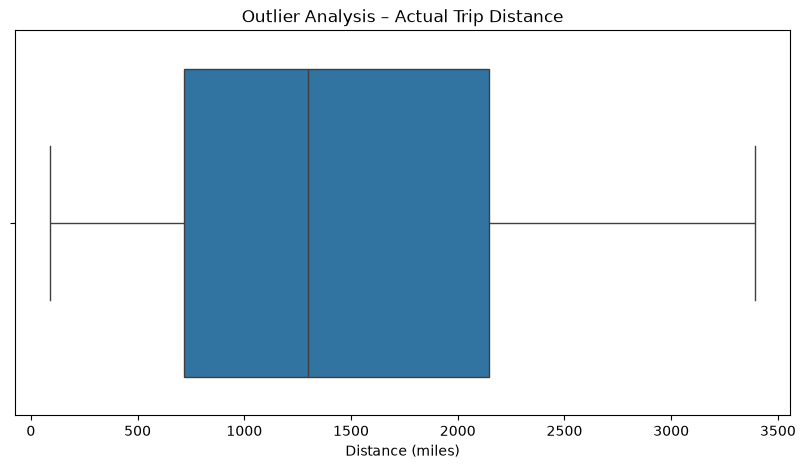

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=trips["actual_distance_miles"]
)

plt.title("Outlier Analysis – Actual Trip Distance")
plt.xlabel("Distance (miles)")

plt.show()

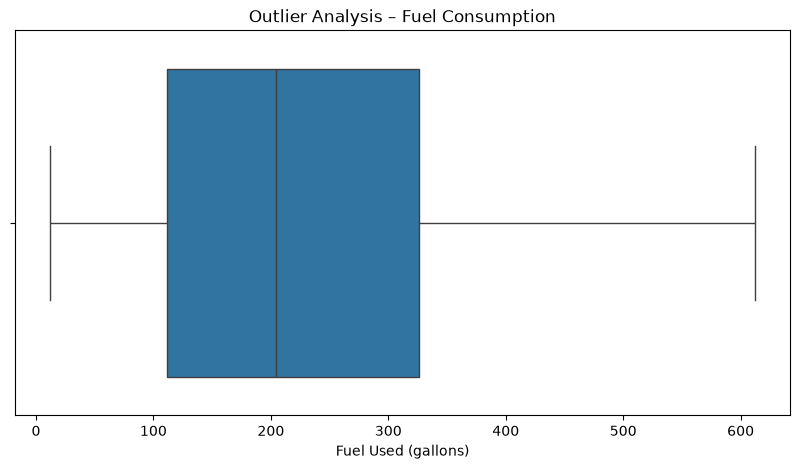

In [17]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=trips["fuel_gallons_used"]
)

plt.title("Outlier Analysis – Fuel Consumption")
plt.xlabel("Fuel Used (gallons)")

plt.show()

In [18]:
numeric_features = [
    "actual_distance_miles",
    "actual_duration_hours",
    "fuel_gallons_used",
    "average_mpg",
    "idle_time_hours"
]

trips_clean = trips.copy()

scaler = StandardScaler()

trips_clean[
    [col + "_scaled" for col in numeric_features]
] = scaler.fit_transform(
    trips_clean[numeric_features]
)

In [19]:
print(
    trips_clean[
        [col + "_scaled" for col in numeric_features]
    ].head()
)

   actual_distance_miles_scaled  actual_duration_hours_scaled  \
0                     -0.144986                      0.083522   
1                     -1.141336                     -1.156626   
2                      1.345174                      1.408225   
3                     -0.889442                     -0.980469   
4                      1.013473                      0.703595   

   fuel_gallons_used_scaled  average_mpg_scaled  idle_time_hours_scaled  
0                 -0.300474            1.121866               -1.217977  
1                 -1.013190           -1.732370                0.447261  
2                  0.926630            1.554326                1.730882  
3                 -0.881235           -0.002530                0.898263  
4                  0.846035            0.551019                1.592112  


In [20]:
print(
    trips_clean[
        [col + "_scaled" for col in numeric_features]
    ].mean()
)

actual_distance_miles_scaled    4.525644e-17
actual_duration_hours_scaled   -2.755319e-16
fuel_gallons_used_scaled       -3.593894e-17
average_mpg_scaled              1.292138e-15
idle_time_hours_scaled         -1.061530e-16
dtype: float64


In [21]:
print(
    trips_clean[
        [col + "_scaled" for col in numeric_features]
    ].std()
)

actual_distance_miles_scaled    1.000006
actual_duration_hours_scaled    1.000006
fuel_gallons_used_scaled        1.000006
average_mpg_scaled              1.000006
idle_time_hours_scaled          1.000006
dtype: float64
